In [1]:
%matplotlib inline

from matplotlib import pyplot
import numpy, scipy

pyplot.rc('figure', figsize=[12, 8], dpi=144)
pyplot.rc('text', usetex=True)

In [2]:
# Estimate particle number densities
# TODO: Implement higher excitation states and corresponding bound-bound and bound-free cross-sections
# Current implementation wouldn't result in Balmer lines

def degeneracy(n):
    return 2 * n ** 2

def energy(n):
    return -13.6 * scipy.constants.e / n ** 2

def excitation_number_densities(temperature, highest_excitation_state=2):
    relative_densities = numpy.array([degeneracy(n) * numpy.exp(-energy(n) / (scipy.constants.k * temperature)) for n in range(1, highest_excitation_state + 1)])
    return relative_densities / relative_densities.sum()

def ion_number_densities(total_number_density, temperature, highest_excitation_state=2):
    z1 = sum(degeneracy(n) * numpy.exp(-(energy(n) - energy(1))/(scipy.constants.k * temperature)) for n in range(1, highest_excitation_state + 1))
    c = (1/total_number_density) * (2 / z1) * (2 * numpy.pi * scipy.constants.m_e * scipy.constants.k * temperature / scipy.constants.h ** 2) ** 1.5 * numpy.exp(energy(1)/(scipy.constants.k * temperature))
    ion_number_density = (c * numpy.sqrt(1 + 4/c) - c) / 2
    return numpy.array([1 - ion_number_density, ion_number_density])

n, t = 1e25, 20000
h, h_plus = n * ion_number_densities(n, t)
h1, h2 = h * excitation_number_densities(t)
print(h1, h2, h_plus)

6.015147102789904e+24 6.471714788354549e+22 3.9201357493265515e+24


In [3]:
# Estimate interaction cross-sections

thomson_scattering_cross_section = 6.65e-29 # m2

def bound_free_cross_section(n, wavelength):
    return numpy.where(wavelength < n ** 2 / scipy.constants.Rydberg, (1.31e-19 / n ** 5) * (wavelength * 1e9 / 500) ** 3, 0.)

def doppler_width(temperature, line_wavelength=121.57e-9):
    thermal_velocity = numpy.sqrt(2 * scipy.constants.k * temperature / scipy.constants.m_p)
    return thermal_velocity / line_wavelength

def doppler_line_profile(wavelength, temperature, line_wavelength=121.57e-9):
    return scipy.stats.norm.pdf(scipy.constants.c / wavelength, loc=scipy.constants.c / line_wavelength, scale=doppler_width(temperature, line_wavelength=line_wavelength) / numpy.sqrt(2))

def bound_bound_cross_section(wavelength, temperature, nl, nu):
    return (scipy.constants.e ** 2 / (4 * scipy.constants.epsilon_0 * scipy.constants.m_e * scipy.constants.c)) * 0.4162 * (1 - nu/(4 * nl)) * doppler_line_profile(wavelength, temperature)

A = (numpy.sqrt(32 * numpy.pi) * scipy.constants.e ** 6) / ((3 * numpy.sqrt(3) * scipy.constants.h * scipy.constants.c ** 4) * numpy.sqrt(scipy.constants.k * scipy.constants.m_e ** 3))

def gaunt_factor(wavelength, temperature):
    energy_ratio = (scipy.constants.k * temperature * wavelength) / (scipy.constants.h * scipy.constants.c)
    return numpy.where(energy_ratio < 1, numpy.sqrt(energy_ratio), (numpy.sqrt(3) / numpy.pi) * (numpy.log(4 * energy_ratio) - 0.577))

def free_free_cross_section(wavelength, temperature, ion_number_density):
    return gaunt_factor(wavelength, temperature) * ion_number_density * (A * wavelength ** 3) / numpy.sqrt(temperature)

bound_bound_cross_section(121.57e-9, 40000, 26764548027710.332, 5552345311446.773)

np.float64(2.7953702213815354e-18)

144.85 1.3106147760628462e+16 1.3106156717707506e+16


(array([ 520.,  632.,  700.,  783.,  724.,  846.,  846.,  853.,  942.,
        1017., 1056., 1096., 1088., 1187., 1234., 1340., 1289., 1416.,
        1381., 1429., 1529., 1524., 1622., 1645., 1682., 1734., 1733.,
        1752., 1786., 1817., 1807., 2026., 1889., 1927., 2023., 2081.,
        2072., 2142., 2237., 2213., 2228., 2295., 2184., 2286., 2280.,
        2293., 2367., 2343., 2331., 2478., 2443., 2354., 2399., 2505.,
        2445., 2363., 2375., 2523., 2386., 2520., 2534., 2368., 2474.,
        2500., 2450., 2574., 2501., 2523., 2531., 2478., 2507., 2515.,
        2506., 2477., 2468., 2547., 2485., 2474., 2434., 2428., 2393.,
        2420., 2464., 2310., 2548., 2335., 2363., 2369., 2434., 2318.,
        2271., 2376., 2353., 2329., 2305., 2368., 2166., 2351., 2218.,
        2167., 2219., 2222., 2289., 2196., 2231., 2167., 2067., 2116.,
        2073., 2025., 2088., 2152., 2051., 2081., 2038., 2083., 2000.,
        2048., 1992., 1892., 2055., 1928., 1853., 1895., 1926., 1924.,
      

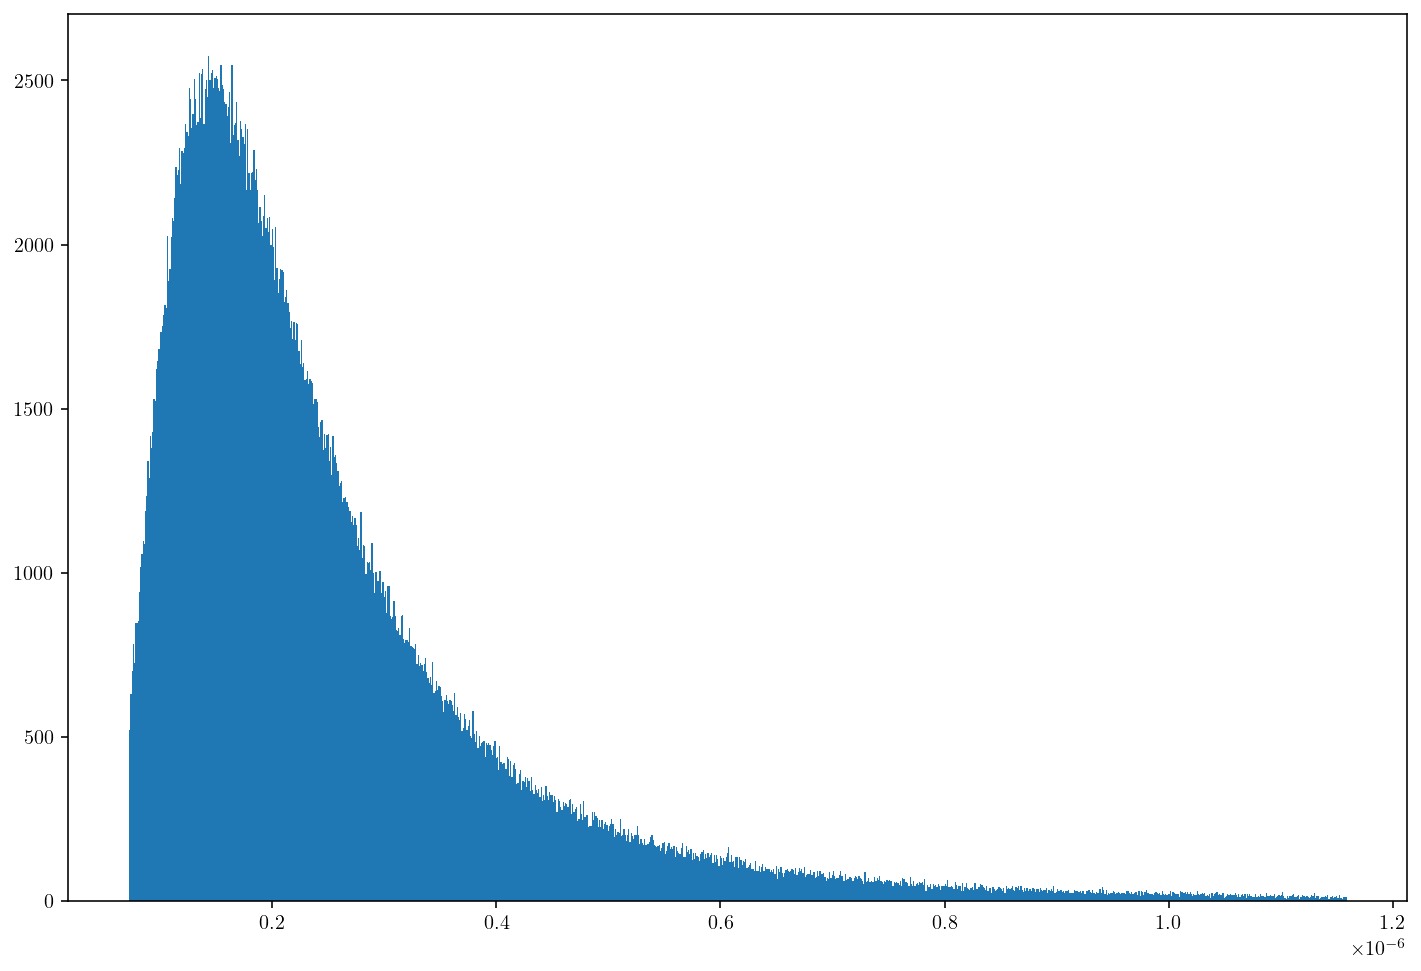

In [4]:
def spectral_radiance(wavelength, temperature):
    return (2 * scipy.constants.h * scipy.constants.c ** 2 / wavelength ** 5) / (numpy.exp(scipy.constants.h * scipy.constants.c / (scipy.constants.k * wavelength * temperature)) - 1)

def black_body_source(temperature, n_photons=1000):
    wavelength_max_radiance = 2.897e-3 / temperature
    max_spectral_radiance = spectral_radiance(wavelength_max_radiance, temperature)
    wavelengths = numpy.random.uniform(0.5 * wavelength_max_radiance, 8 * wavelength_max_radiance, int(n_photons * 2.5))
    generated_radiance = numpy.random.uniform(0, max_spectral_radiance, int(n_photons * 2.5))
    actual_radiance = spectral_radiance(wavelengths, temperature)
    print(wavelength_max_radiance * 1e9, generated_radiance.max(), max_spectral_radiance)
    return wavelengths[generated_radiance < actual_radiance]

pyplot.hist(black_body_source(20000, n_photons=1000000), 1000)

144.85 1.3106153846746258e+16 1.3106156717707506e+16
3913899695141656.0 42109764074491.87 9.999604399054078e+19
0.016274642350276515 3.1038906178323736e-06 6.678985363682081e-08 1.472171244697918e-37 6.6497369253709625e-09 0.01627463322269664


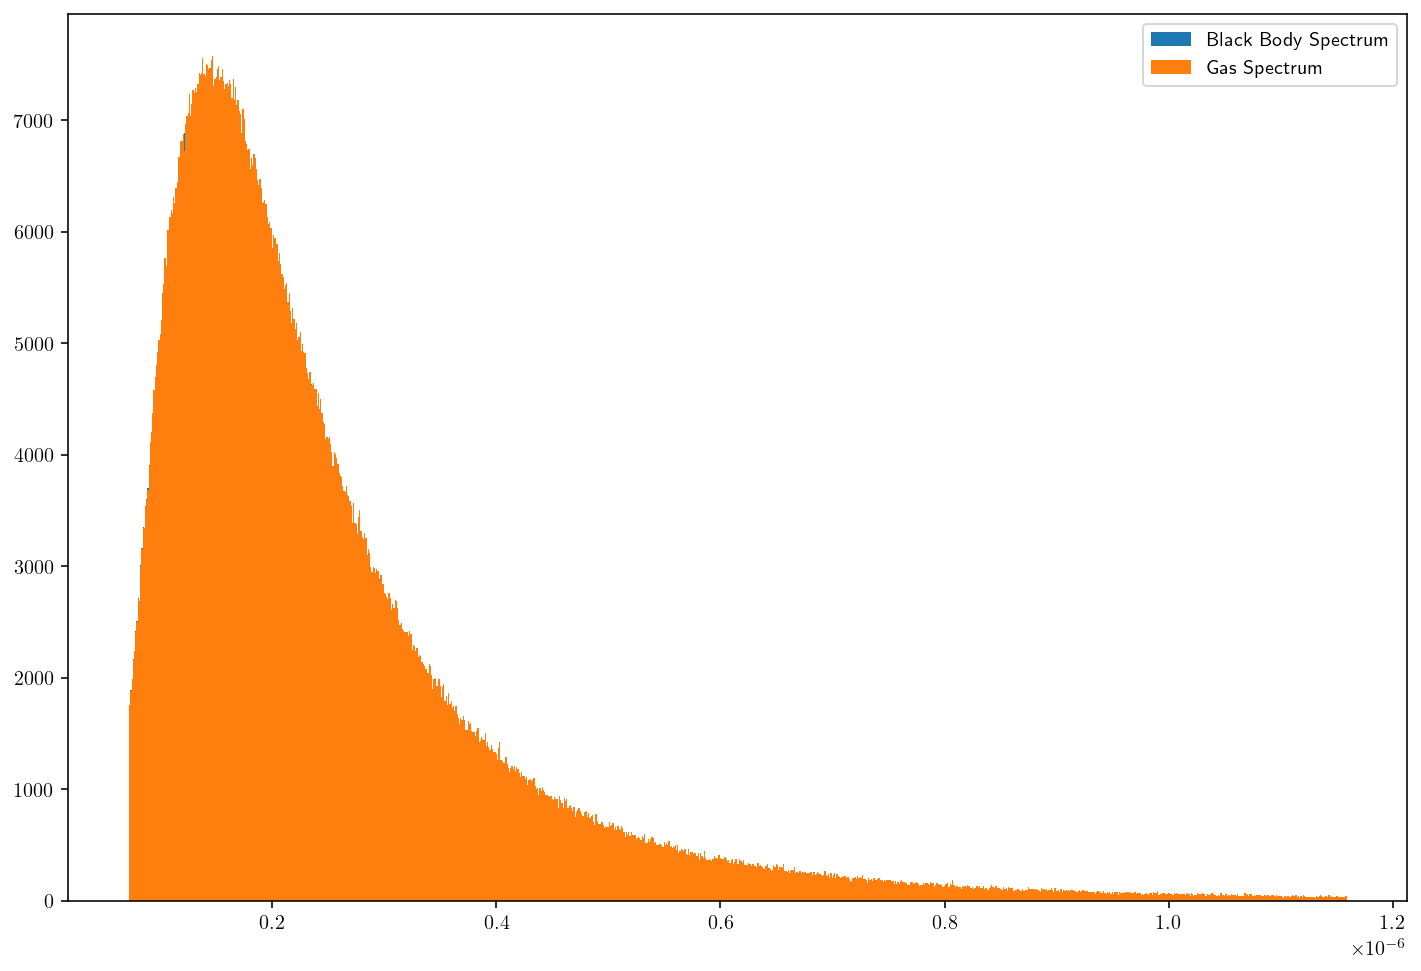

In [5]:
def simulate():
    n_steps = 1000
    temperature = 20000
    n_photons = 3000000
    particle_number_density = 1e20
    wavelengths = black_body_source(temperature, n_photons)
    h_density, proton_density = particle_number_density * ion_number_densities(particle_number_density, temperature)
    h1_density, h2_density = h_density * excitation_number_densities(temperature)
    print(h1_density, h2_density, proton_density)
    h1_bf_opacity = h1_density * bound_free_cross_section(1, wavelengths)
    h2_bf_opacity = h2_density * bound_free_cross_section(2, wavelengths)
    free_free_opacity = proton_density * free_free_cross_section(wavelengths, temperature, proton_density)
    thomson_scattering_opacity = proton_density * thomson_scattering_cross_section
    h1_bb_opacity = h1_density * bound_bound_cross_section(wavelengths, temperature, h1_density, h2_density)
    opacity = (h1_bf_opacity + h2_bf_opacity + free_free_opacity + h1_bb_opacity + thomson_scattering_opacity)
    print(opacity.max(), h1_bf_opacity.max(), h2_bf_opacity.max(), free_free_opacity.max(), thomson_scattering_opacity, h1_bb_opacity.max())
    absorbed = numpy.zeros(wavelengths.size, dtype=numpy.bool)
    for i in range(n_steps):
        absorbed |= (numpy.random.random(wavelengths.size) < opacity)
    survived = wavelengths[~absorbed]
    pyplot.hist(wavelengths, 1000, label='Black Body Spectrum')
    pyplot.hist(survived, 1000, label='Gas Spectrum')
    pyplot.legend()
    return wavelengths, survived

wavelengths, survived = simulate()


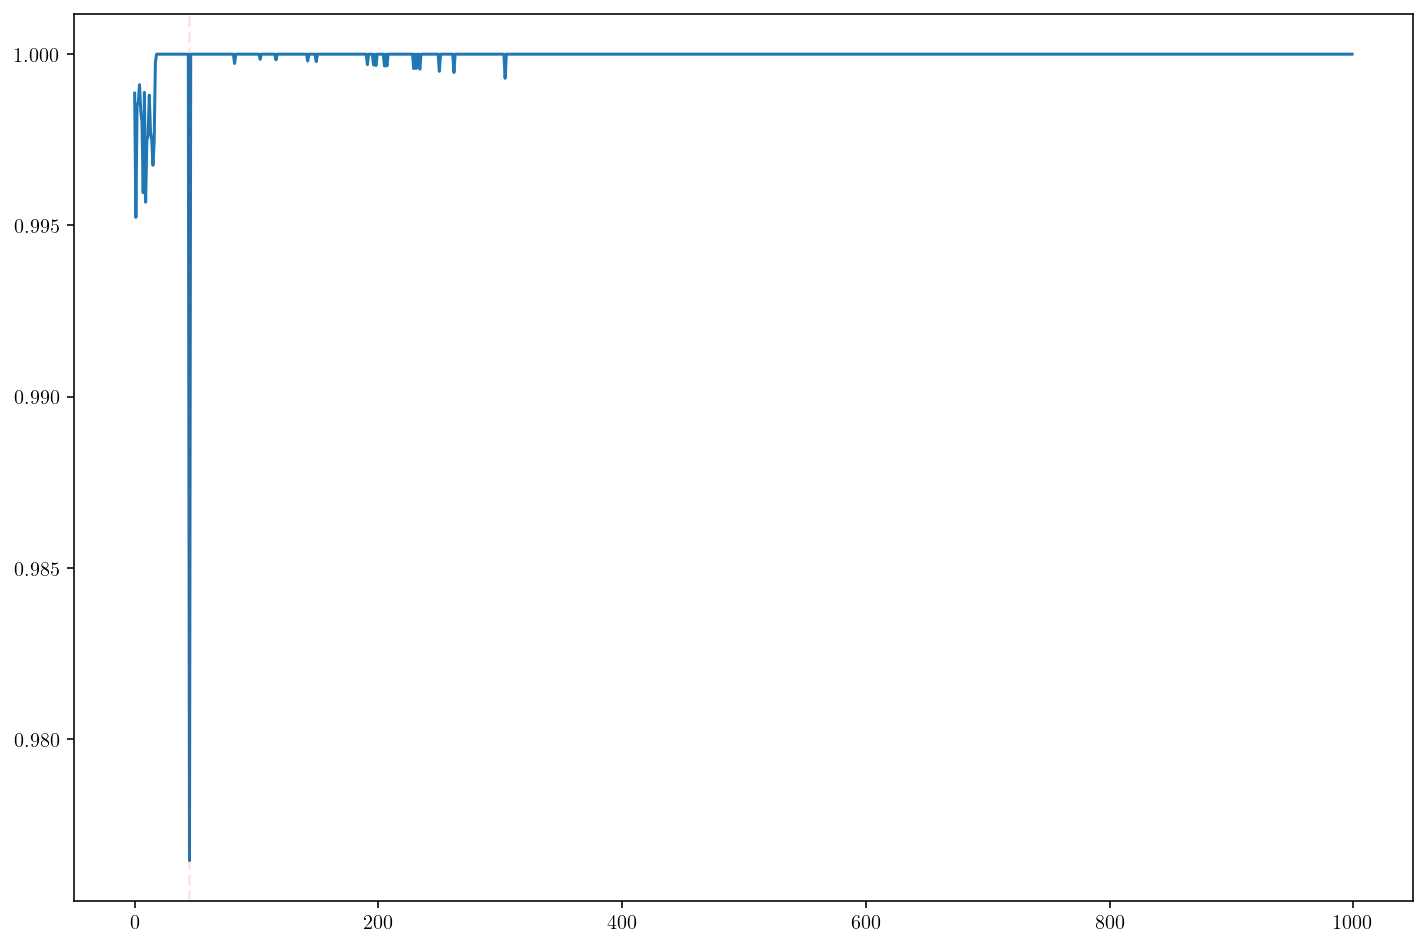

In [6]:
from collections import defaultdict

n_bins = 1000
bin_width = (wavelengths.max() - wavelengths.min()) / n_bins
input_bins = numpy.asarray((wavelengths - wavelengths.min())//bin_width, dtype=numpy.int16)
input_spectrum = defaultdict(int)
for bin in input_bins:
    input_spectrum[bin] += 1
output_bins = numpy.asarray((survived - wavelengths.min())//bin_width, dtype=numpy.int16)
output_spectrum = defaultdict(int)
for bin in output_bins:
    output_spectrum[bin] += 1
bins = numpy.arange(0, 1000)
intensity_ratio = [output_spectrum[bin]/input_spectrum[bin] for bin in bins]
pyplot.plot(bins, intensity_ratio)
pyplot.axvline((121.57e-9 - wavelengths.min())//bin_width, linestyle='--', color='r', alpha=0.1)